# Memorization Type 1: Same Patterns, Different Locations

This notebook is part of the broader memorization analysis framework for mobility sequence predictors. The goal of this notebook is to analyze **memorization of exact location sequences**, independent of abstract mobility patterns.

In particular, we implement and evaluate memorization behavior of a trained model with respect to:
- **Original training trajectories** from real users.
- **Reference trajectories** that preserve the same movement patterns (e.g., displacements, directions, temporal rhythms), but with **different geographic anchor points**.

This helps identify whether the model has memorized exact spatial sequences, rather than generalizable behavioral patterns.

The notebook performs the following:
1. Load and preprocess user trajectories.
2. Normalize trajectories to isolate spatial patterns.
3. Cluster users with similar patterns.
4. Construct reference sets with pattern-preserving, location-altered versions.
5. Evaluate likelihoods of original and reference trajectories using the trained model.
6. Compute memorization metrics (e.g., percentile rank, likelihood gap).


In [214]:
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from haversine import haversine
import matplotlib.pyplot as plt
import random
sys.path.append('./Helpers/')
from utils import save_dict, load_dict
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import pairwise_distances
from collections import defaultdict
from sklearn.cluster import KMeans
from fastdtw import fastdtw
from scipy.spatial.distance import squareform
from sklearn.cluster import AgglomerativeClustering
import numpy as np
from tqdm import tqdm  
from geopy.distance import geodesic
from datetime import timedelta

In [246]:
DATASET_NAME_TO_FOLDER_NAME = {
    'boston': 'Boston',
    'geolife': 'Geolife',
    'shenzhenurban': 'ShenzhenUrban',
    'shanghaikaggle': 'ShanghaiKaggle',
    'yjmob100k': 'YJMob100Kv3'
}
dataset_name = "shanghaikaggle"
version = 0
save_path_base = (
    Path('PreprocessedData/2SplittedData') /
    DATASET_NAME_TO_FOLDER_NAME[dataset_name] /
    'NormalizationType1' 
)

save_path_data_abstraction = (
    Path('PreprocessedData/2SplittedData') /
    DATASET_NAME_TO_FOLDER_NAME[dataset_name] /
    'NormalizationType1' /
    'abstracted_trajectory_records.dict'
)

save_path_data_datasets = (
    Path('PreprocessedData/2SplittedData') /
    DATASET_NAME_TO_FOLDER_NAME[dataset_name] /
    'NormalizationType1' /
    'Datasets/'
)

In [247]:
df = pd.read_pickle(Path('PreprocessedData/1FilteredData/') / DATASET_NAME_TO_FOLDER_NAME[dataset_name]/str(version)/'dataset.pkl', compression=None)
location_df = pd.read_csv(Path('PreprocessedData/1FilteredData/') / DATASET_NAME_TO_FOLDER_NAME[dataset_name]/str(version)/'dictionary.csv')
location_dict = location_df.set_index('Location')[['Latitude', 'Longitude']].apply(tuple, axis=1).to_dict()

In [248]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['date'] = df['Timestamp'].dt.date
df['Latitude'] = df['Location'].map(location_dict).str[0]
df['Longitude'] = df['Location'].map(location_dict).str[1]
traj_df = df[['DeviceID', 'date']].drop_duplicates().reset_index().rename(columns={'index': 'traj_id'})
df = df.merge(right=traj_df, on=['DeviceID', 'date'])

## Dataset abstraction

In [134]:
def haversine_vectorized(origin, destinations):
    R = 6371  # Earth radius in kilometers
    lat1 = np.radians(origin[0])
    lon1 = np.radians(origin[1])
    lat2 = np.radians(destinations[:, 0])
    lon2 = np.radians(destinations[:, 1])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c *1000  # distance in m

def abstract_trajectories_by_distance(df):
    trajectory_records = []

    for traj_id, group in df.groupby('traj_id'):
        group = group.sort_values('Timestamp')
        coords = group[['Latitude', 'Longitude']].to_numpy()

        if len(coords) != 48:
            print(f"Skipping traj_id {traj_id}: incomplete trajectory")
            continue

        origin = tuple(coords[0])  # (lat, lon)
        device_id = group['DeviceID'].iloc[0]

        # Raw distances from origin
        distances_km = [-1 if np.isnan(coord).any() else round(haversine(origin, tuple(coord))) for coord in coords]

        trajectory_records.append({
            'traj_id': traj_id,
            'DeviceID': device_id,
            'origin': origin,
            'pattern': distances_km  # list of int distances
        })

    return trajectory_records

def abstract_k_day_trajectories_by_distance(df, k=3):
    """
    Build trajectory records for k-day chunks per user.
    Each record is a normalized distance pattern from the origin (first point).
    """
    trajectory_records = []
    expected_len = 48 * k  # 48 points per day

    for device_id, user_df in df.groupby('DeviceID'):
        user_df = user_df.sort_values('Timestamp')
        unique_dates = sorted(user_df['date'].unique())

        for i in range(0, len(unique_dates) - k + 1, k):
            selected_dates = unique_dates[i:i + k]
            chunk_df = user_df[user_df['date'].isin(selected_dates)].sort_values('Timestamp')

            if len(chunk_df) != expected_len:
                continue  # skip incomplete chunks

            coords = chunk_df[['Latitude', 'Longitude']].to_numpy()
            origin = coords[0]

            # Mask valid rows
            mask = ~np.isnan(coords).any(axis=1)
            distances = np.full(len(coords), -1)  # start with -1

            if np.any(mask):
                clean_coords = coords[mask]
                dists = haversine_vectorized(origin, clean_coords)
                binned = np.where(dists == 0, 0, np.ceil(dists).astype(int))
                distances[mask] = binned

            trajectory_records.append({
                'traj_id': f"{device_id}_{selected_dates[0]}_{selected_dates[-1]}",
                'DeviceID': device_id,
                'origin': tuple(origin),
                'pattern': distances.tolist()
            })

    return trajectory_records


def abstract_k_day_trajectories_by_displacement(df, k=3):
    """
    Build trajectory records for k-day chunks per user.
    Each record contains (Δlat, Δlon) displacements for k * 48 timesteps.
    Missing points are treated as no movement (0.0, 0.0).
    """
    trajectory_records = []
    expected_len = 48 * k

    for device_id, user_df in df.groupby('DeviceID'):
        user_df = user_df.sort_values('Timestamp')
        #unique_dates = sorted(user_df['date'].unique())
        unique_trajs = sorted(user_df['traj_id'].unique())

        for i in range(0, len(unique_trajs) - k + 1, k):
            #selected_dates = unique_dates[i:i + k]
            selected_trajs = unique_trajs[i:i + k]
            chunk_df = user_df[user_df['traj_id'].isin(selected_trajs)].sort_values('Timestamp')

            if len(chunk_df) != expected_len:
                continue

            coords = chunk_df[['Latitude', 'Longitude']].to_numpy()

            # Replace NaNs with origin if first point is valid, else skip
            origin = coords[0]
            if np.isnan(origin).any():
                continue

            coords = np.nan_to_num(coords, nan=origin)  # fill NaNs with origin (no movement)

            # Compute Δlat, Δlon
            deltas = np.diff(coords, axis=0, prepend=[coords[0]])

            trajectory_records.append({
                'traj_id': f"{selected_trajs[0]}_{selected_trajs[-1]}",
                'DeviceID': device_id,
                'origin': tuple(origin),
                'pattern': deltas.tolist()
            })

    return trajectory_records


In [135]:
df

,DeviceID,Timestamp,Location,date,Latitude,Longitude,traj_id
0,0010eb6cd724b3d5fda54cbba05c23f6,2014-06-17 00:00:00,1474,2014-06-17,31.176998,121.423586,0
1,0010eb6cd724b3d5fda54cbba05c23f6,2014-06-17 00:30:00,1474,2014-06-17,31.176998,121.423586,0
2,0010eb6cd724b3d5fda54cbba05c23f6,2014-06-17 01:00:00,1474,2014-06-17,31.176998,121.423586,0
3,0010eb6cd724b3d5fda54cbba05c23f6,2014-06-17 01:30:00,1474,2014-06-17,31.176998,121.423586,0
4,0010eb6cd724b3d5fda54cbba05c23f6,2014-06-17 02:00:00,1474,2014-06-17,31.176998,121.423586,0
...,...,...,...,...,...,...,...
3860203,fffd23d0da480c4032ed19c2fe7cbfae,2014-09-24 21:30:00,1375,2014-09-24,31.195131,121.418788,3860160
3860204,fffd23d0da480c4032ed19c2fe7cbfae,2014-09-24 22:00:00,1274,2014-09-24,31.201647,121.420098,3860160
3860205,fffd23d0da480c4032ed19c2fe7cbfae,2014-09-24 22:30:00,1375,2014-09-24,31.195131,121.418788,3860160
3860206,fffd23d0da480c4032ed19c2fe7cbfae,2014-09-24 23:00:00,1505,2014-09-24,31.195907,121.410659,3860160


In [8]:
trajectory_records_k3 = abstract_k_day_trajectories_by_displacement(df)

In [9]:
len(trajectory_records_k3)

22993

In [10]:
#Saving the first part after normalization
save_dict(trajectory_records_k3, save_path_data_abstraction)

Saved to: PreprocessedData/2SplittedData/ShanghaiKaggle/NormalizationType1/abstracted_trajectory_records.dict


In [61]:
for dataset_name in DATASET_NAME_TO_FOLDER_NAME:
    save_path_data_abstraction = (
        Path('PreprocessedData/2SplittedData') /
        DATASET_NAME_TO_FOLDER_NAME[dataset_name] /
        'NormalizationType1' /
        'abstracted_trajectory_records.dict'
    )
    try:
        trajectory_records = load_dict(save_path_data_abstraction)  
        print(f"Dataset: {dataset_name}")
        print(len(trajectory_records))
    except Exception as e:
        print(f"Failed to load dataset {dataset_name}: {e}")

Failed to load dataset boston: [Errno 2] No such file or directory: 'PreprocessedData/2SplittedData/Boston/NormalizationType1/abstracted_trajectory_records.dict'
Failed to load dataset geolife: [Errno 2] No such file or directory: 'PreprocessedData/2SplittedData/Geolife/NormalizationType1/abstracted_trajectory_records.dict'
Loaded from: PreprocessedData/2SplittedData/ShenzhenUrban/NormalizationType1/abstracted_trajectory_records.dict
Dataset: shenzhenurban
303779
Loaded from: PreprocessedData/2SplittedData/ShanghaiKaggle/NormalizationType1/abstracted_trajectory_records.dict
Dataset: shanghaikaggle
22993
Loaded from: PreprocessedData/2SplittedData/YJMob100Kv3/NormalizationType1/abstracted_trajectory_records.dict
Dataset: yjmob100k
398440


## Trajectories Clustering

In [189]:
trajectory_records = load_dict(save_path_data_abstraction)

Loaded from: PreprocessedData/2SplittedData/YJMob100Kv3/NormalizationType1/abstracted_trajectory_records.dict


In [190]:
nclusters = 2000
min_cluster_size = 100

In [191]:
# Flatten each 2D pattern (seq_len x 2) into 1D: x0 y0 x1 y1 ...
X = [np.array(traj['pattern']).flatten() for traj in trajectory_records]
X = np.stack(X)

# Run KMeans
kmeans = KMeans(n_clusters=nclusters, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X)

# Assign cluster labels back
for traj, label in zip(trajectory_records, labels):
    traj['cluster'] = label

In [192]:
def get_cluster_medoids_safe(
    trajectory_records,
    kmeans_centroids,
    max_cluster_size=500,
    epsilon_init=0.05,
    epsilon_min=1e-4,
    epsilon_max=0.5,
    max_iterations=10
):
    """
    For small clusters (≤ max_cluster_size): compute true medoid (pairwise).
    For large clusters: adaptively search for bounding box around centroid to select points,
    then pick closest one to the centroid.

    Returns:
        List of medoid trajectory dicts (1 per cluster)
    """
    cluster_groups = defaultdict(list)
    for traj in trajectory_records:
        cluster_groups[traj['cluster']].append(traj)

    medoids = []

    for cluster_id, trajs in cluster_groups.items():
        centroid = kmeans_centroids[cluster_id]
        centroid = centroid / (np.linalg.norm(centroid) + 1e-10)

        vectors = [np.array(t['pattern']).flatten() for t in trajs]
        vectors = np.stack(vectors)
        vectors = vectors / (np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-10)

        if len(trajs) <= max_cluster_size:
            # Safe to compute true medoid
            dists = pairwise_distances(vectors, metric='euclidean')
            medoid_idx = np.argmin(dists.sum(axis=1))
            medoid_traj = trajs[medoid_idx]
        else:
            # Adaptive bounding box
            epsilon = epsilon_init
            best_filtered = None

            for _ in range(max_iterations):
                lower = centroid - epsilon
                upper = centroid + epsilon
                mask = np.all((vectors >= lower) & (vectors <= upper), axis=1)
                filtered = np.where(mask)[0]

                if len(filtered) == 0:
                    epsilon *= 2  # too narrow, expand
                    if epsilon > epsilon_max:
                        break
                elif len(filtered) > max_cluster_size:
                    epsilon /= 2  # too wide, shrink
                    if epsilon < epsilon_min:
                        break
                else:
                    best_filtered = filtered
                    break  # good range

            # If we found a filtered set, use it
            if best_filtered is not None and len(best_filtered) > 0:
                filtered_vecs = vectors[best_filtered]
                dists = pairwise_distances([centroid], filtered_vecs, metric='euclidean')[0]
                closest_idx = best_filtered[np.argmin(dists)]
                medoid_traj = trajs[closest_idx]
            else:
                # Fallback: use closest to centroid from all
                dists = pairwise_distances([centroid], vectors, metric='euclidean')[0]
                medoid_idx = np.argmin(dists)
                medoid_traj = trajs[medoid_idx]

        medoid_traj['cluster'] = cluster_id
        medoids.append(medoid_traj)

    return medoids

medoids = get_cluster_medoids_safe(
    trajectory_records,
    kmeans_centroids=kmeans.cluster_centers_,
    max_cluster_size=500
)

In [193]:
# Group trajectories by cluster
cluster_groups = defaultdict(list)
for traj in trajectory_records:
    cluster_id = traj['cluster']
    cluster_groups[cluster_id].append(traj)

#cluster sizes
cluster_sizes = {"key":[], "size":[]}
for cluster in cluster_groups:
   cluster_sizes['key'].append(cluster)
   cluster_sizes['size'].append(len(cluster_groups[cluster]))
cluster_sizes = pd.DataFrame(cluster_sizes)
cluster_sizes.describe()

,key,size
count,2000.000000,2000.000000
mean,999.500000,199.220000
std,577.494589,1532.350385
min,0.000000,1.000000
25%,499.750000,1.000000
50%,999.500000,40.000000
75%,1499.250000,155.250000
max,1999.000000,64795.000000


In [194]:


def build_reference_sets_cluster_enrichment(
    trajectory_records,
    medoids,  # List of medoid traj dicts, 1 per cluster
    min_cluster_size=100,
):
    """
    Enrich small clusters with points from nearby clusters, using medoid-to-medoid distances.
    
    Parameters:
        trajectory_records: list of all trajectory dicts (with 'traj_id', 'cluster', 'pattern')
        medoids: list of cluster medoid trajectory dicts (1 per cluster)
        min_cluster_size: minimum number of references desired

    Returns:
        training_set: list of training trajectories (medoids)
        reference_sets: dict {train_traj_id: list of reference trajectories}
    """
    # Build lookup tables
    cluster_groups = defaultdict(list)
    for traj in trajectory_records:
        cluster_groups[traj['cluster']].append(traj)

    all_clusters = sorted(cluster_groups.keys())
    medoid_vectors = [np.array(m['pattern']).flatten() for m in medoids]
    medoid_vectors = np.stack(medoid_vectors)
    medoid_vectors = medoid_vectors / (np.linalg.norm(medoid_vectors, axis=1, keepdims=True) + 1e-10)

    cluster_id_to_medoid = {m['cluster']: m for m in medoids}
    cluster_id_to_vector = {m['cluster']: v for m, v in zip(medoids, medoid_vectors)}
    traj_id_to_vector = {t['traj_id']: np.array(t['pattern']).flatten() for t in trajectory_records}

    training_set = []
    reference_sets = {}

    # Compute cluster-to-cluster distance matrix
    cluster_dist = pairwise_distances(medoid_vectors, metric='euclidean')
    cluster_dist_argsort = np.argsort(cluster_dist, axis=1)  # pre-sorted for fast lookup

    for idx, cluster_id in enumerate(all_clusters):
        cluster_trajs = cluster_groups[cluster_id]
        medoid = cluster_id_to_medoid[cluster_id]
        train_tid = medoid['traj_id']
        training_set.append(medoid)

        in_cluster_refs = [t for t in cluster_trajs if t['traj_id'] != train_tid]
        needed = max(0, min_cluster_size - len(in_cluster_refs))
        collected_refs = in_cluster_refs.copy()
        seen_tids = {t['traj_id'] for t in collected_refs}
        seen_tids.add(train_tid)

        # Start checking other clusters in order of proximity
        neighbor_idx_list = cluster_dist_argsort[idx]
        for neighbor_idx in neighbor_idx_list:
            neighbor_cluster = all_clusters[neighbor_idx]
            if neighbor_cluster == cluster_id:
                continue  # skip self

            neighbor_trajs = cluster_groups[neighbor_cluster]
            candidate_trajs = [t for t in neighbor_trajs if t['traj_id'] not in seen_tids]

            if len(candidate_trajs) <= needed:
                collected_refs.extend(candidate_trajs)
                seen_tids.update(t['traj_id'] for t in candidate_trajs)
                needed -= len(candidate_trajs)
            else:
                # Pick top-N closest to medoid
                medoid_vec = cluster_id_to_vector[cluster_id]
                cand_vecs = np.stack([traj_id_to_vector[t['traj_id']] for t in candidate_trajs])
                cand_vecs = cand_vecs / (np.linalg.norm(cand_vecs, axis=1, keepdims=True) + 1e-10)
                dists = pairwise_distances([medoid_vec], cand_vecs, metric='euclidean')[0]
                sorted_idxs = np.argsort(dists)[:needed]
                selected = [candidate_trajs[i] for i in sorted_idxs]
                collected_refs.extend(selected)
                break  # done

            if needed <= 0:
                break

        reference_sets[train_tid] = collected_refs

    return training_set, reference_sets

training_set, reference_sets =  build_reference_sets_cluster_enrichment(trajectory_records=trajectory_records, medoids=medoids, min_cluster_size=min_cluster_size)

In [195]:
save_dict(training_set, save_path_base / "training_set.pkl")
save_dict(reference_sets, save_path_base / "reference_sets.pkl")

Saved to: PreprocessedData/2SplittedData/YJMob100Kv3/NormalizationType1/training_set.pkl
Saved to: PreprocessedData/2SplittedData/YJMob100Kv3/NormalizationType1/reference_sets.pkl


In [196]:
cluster_sizes= []
for key in reference_sets:
    cluster_sizes.append(len(reference_sets[key]))
pd.Series(cluster_sizes).describe()

count     2000.000000
mean       250.696500
std       1526.522057
min        100.000000
25%        100.000000
50%        100.000000
75%        154.250000
max      64794.000000
dtype: float64

In [197]:
def save_training_and_reference_sets(training_set, reference_sets, df, output_folder):
    """
    Save training and reference trajectory sets into CSV files with safety checks.

    Args:
        training_set: List of training trajectory dicts (with 'traj_id')
        reference_sets: Dict {train_traj_id → list of trajectory dicts}
        df: Original DataFrame with all GPS records (must include 'traj_id', 'Latitude', 'Longitude', 'Timestamp')
        output_folder: Folder path to save training_set.csv, cluster_*.csv, and mapping
    """
    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)

    df = df.set_index('traj_id')
    training_rows = []
    mapping_rows = []

    print(f"\n📦 Saving training and reference sets to {output_path.resolve()}")

    for train_traj in training_set:
        train_tid = train_traj['traj_id']
        cluster_file = f"cluster_{train_tid}.csv"
        out_file = output_path / cluster_file

        # Sanity check: already saved?
        if out_file.exists():
            print(f"⏭️ Skipping {cluster_file}, already exists.")
            continue

        print(f"🧭 Processing {cluster_file}")
        mapping_rows.append({
            'cluster_file': cluster_file,
            'representant_tid': train_tid
        })

        # Save training trajectory
        try:
            tid_min, tid_max = map(int, train_tid.split('_'))
            train_df = df.loc[tid_min:tid_max].copy()
            if train_df.empty:
                print(f"⚠️  Skipped empty training trajectory {train_tid}")
                continue
            train_df['tid'] = train_tid
            training_rows.append(train_df)
        except KeyError:
            print(f"⚠️  Training trajectory {train_tid} not found in df.")
            continue

        # Build and save reference set
        ref_trajs = reference_sets.get(train_tid, [])
        ref_rows = []
        for ref in ref_trajs:
            ref_tid = ref['traj_id']
            try:
                tid_min, tid_max = map(int, ref_tid.split('_'))
                ref_df = df.loc[tid_min:tid_max].copy()
                if ref_df.empty:
                    continue
                ref_df['tid'] = ref_tid
                ref_rows.append(ref_df)
            except KeyError:
                continue

        if not ref_rows:
            print(f"⚠️  No reference trajectories found for {train_tid}")
            continue

        cluster_df = pd.concat(ref_rows).reset_index()
        if 'Latitude' not in cluster_df or 'Longitude' not in cluster_df:
            print(f"⚠️  Malformed reference set for {train_tid}")
            continue

        cluster_df = cluster_df[['tid', 'Timestamp', 'Latitude', 'Longitude']]
        cluster_df.rename(columns={'Timestamp': 'timestamp', 'Latitude': 'lat', 'Longitude': 'lon'}, inplace=True)
        cluster_df[['lat', 'lon']] = cluster_df.groupby('tid')[['lat', 'lon']].transform(lambda g: g.ffill())
        cluster_df.to_csv(out_file, index=False)

    # Save training set
    if training_rows:
        training_df = pd.concat(training_rows)
        training_df = training_df[['tid', 'Timestamp', 'Latitude', 'Longitude']]
        training_df.rename(columns={'Timestamp': 'timestamp', 'Latitude': 'lat', 'Longitude': 'lon'}, inplace=True)
        training_df[['lat', 'lon']] = training_df.groupby('tid')[['lat', 'lon']].transform(lambda g: g.ffill())
        training_df.to_csv(output_path / "training_set.csv", index=False)

        mapping_df = pd.DataFrame(mapping_rows)
        mapping_df.to_csv(output_path / "representant_mapping.txt", index=False)

        print(f"\n✅ Saved training set with {len(training_rows)} trajectories.")
        print(f"📁 Reference clusters saved to: {output_path.resolve()}")
    else:
        print("⚠️ No valid training samples saved.")


In [198]:
save_training_and_reference_sets(training_set, reference_sets, df, save_path_data_datasets)



📦 Saving training and reference sets to YJMob100Kv3/NormalizationType1/Datasets
🧭 Processing cluster_35653248_35653344.csv
🧭 Processing cluster_4304976_4305072.csv
🧭 Processing cluster_45787152_45787248.csv
🧭 Processing cluster_16743552_16743648.csv
🧭 Processing cluster_27077328_27077424.csv
🧭 Processing cluster_45265008_45265104.csv
🧭 Processing cluster_33894336_33894432.csv
🧭 Processing cluster_29677536_29677632.csv
🧭 Processing cluster_50516544_50516640.csv
🧭 Processing cluster_7675728_7675824.csv
🧭 Processing cluster_45846000_45846096.csv
🧭 Processing cluster_22472112_22472208.csv
🧭 Processing cluster_58070640_58070736.csv
🧭 Processing cluster_57346752_57346848.csv
🧭 Processing cluster_27339648_27339744.csv
🧭 Processing cluster_58319520_58319616.csv
🧭 Processing cluster_47738208_47738304.csv
🧭 Processing cluster_17682336_17682432.csv
🧭 Processing cluster_53449152_53449248.csv
🧭 Processing cluster_44229024_44229120.csv
🧭 Processing cluster_55067712_55067808.csv
🧭 Processing cluster

## Sanity checks

In [ ]:
training_set = load_dict(save_path_base / "training_set.pkl")
reference_sets = load_dict(save_path_base / "reference_sets.pkl")


In [42]:
def compute_cluster_spread_stats_from_sets(training_set, reference_sets, max_refs=10000):
    """
    Computes avg and var for both:
    - geodesic distances between training origin and reference origins
    - Euclidean distances between training pattern and reference patterns
    Args:
        training_set: list of trajectory dicts (with 'traj_id', 'origin', 'pattern')
        reference_sets: dict {train_tid → list of reference trajectory dicts}
        max_refs: max number of reference trajs to consider (for huge clusters)

    Returns:
        DataFrame with per-cluster stats
    """
    stats = []

    for train_traj in training_set:
        tid = train_traj['traj_id']
        train_pattern = np.array(train_traj['pattern']).flatten()
        train_origin = train_traj.get('origin')
        refs = reference_sets.get(tid, [])

        if not train_origin or not train_pattern.any() or len(refs) < 2:
            continue

        # Sample if needed
        if len(refs) > max_refs:
            refs = np.random.choice(refs, size=max_refs, replace=False)

        ref_patterns = [np.array(r['pattern']).flatten() for r in refs if r.get('pattern') is not None]
        ref_origins = [r.get('origin') for r in refs if r.get('origin') is not None]

        if len(ref_patterns) < 2 or len(ref_origins) < 2:
            continue

        ref_patterns = np.stack(ref_patterns)

        # Pattern distances
        pattern_dists = np.linalg.norm(ref_patterns - train_pattern, axis=1)
        avg_pattern_dist = np.mean(pattern_dists)
        var_pattern_dist = np.var(pattern_dists)

        # Geo distances
        geo_dists = [geodesic(train_origin, o).km for o in ref_origins]
        avg_geo_dist = np.mean(geo_dists)
        var_geo_dist = np.var(geo_dists)

        stats.append({
            'train_tid': tid,
            'num_refs': len(refs),
            'avg_geo_dist_km': avg_geo_dist,
            'var_geo_dist_km': var_geo_dist,
            'avg_pattern_dist': avg_pattern_dist,
            'var_pattern_dist': var_pattern_dist
        })

    return pd.DataFrame(stats)

In [43]:
spread_df = compute_cluster_spread_stats_from_sets(training_set, reference_sets)
spread_df.describe()

,num_refs,avg_geo_dist_km,var_geo_dist_km,avg_pattern_dist,var_pattern_dist
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,166.494500,14.972557,76.493996,1.018643,0.053509
std,514.926834,7.306949,57.809427,0.506489,0.057194
min,100.000000,1.185865,0.405898,0.014194,0.000006
25%,100.000000,9.563621,30.212432,0.660792,0.010614
50%,100.000000,14.280376,63.321546,1.063531,0.036300
75%,100.000000,19.729147,112.704079,1.394459,0.077536
max,10000.000000,40.288152,295.839936,2.582056,0.479054


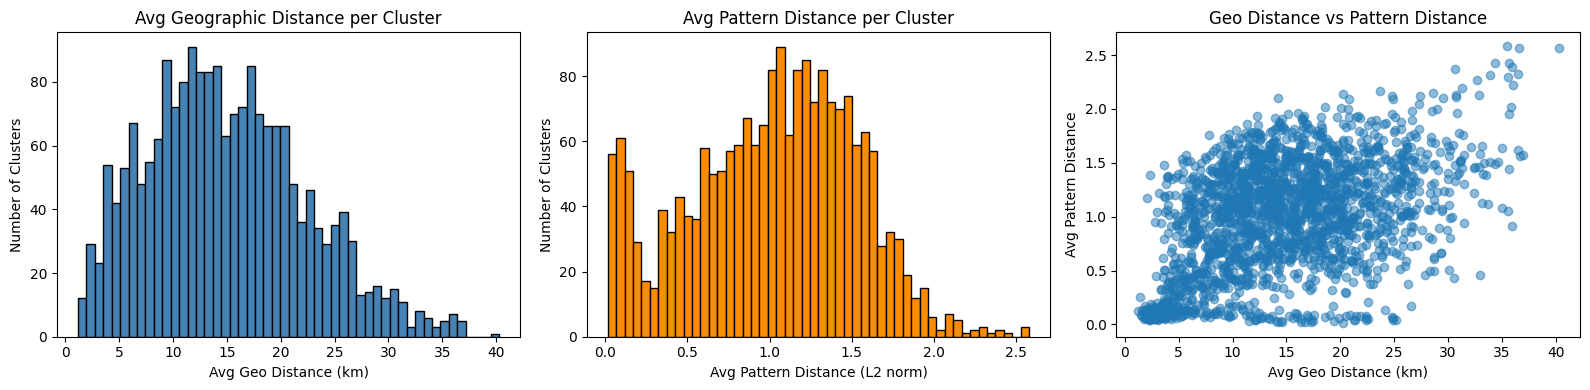

In [ ]:


def plot_geo_pattern_spread_distribution(spread_df):
    """
    Plots:
    - Histogram of average geographic distances (in km)
    - Histogram of average pattern distances (unitless)
    - Scatter plot: geo vs pattern distance
    """
    plt.figure(figsize=(16, 4))

    # Histogram: Geo Distance
    plt.subplot(1, 3, 1)
    plt.hist(spread_df['avg_geo_dist_km'], bins=50, color='steelblue', edgecolor='black')
    plt.title("Avg Geographic Distance per Cluster")
    plt.xlabel("Avg Geo Distance (km)")
    plt.ylabel("Number of Clusters")

    # Histogram: Pattern Distance
    plt.subplot(1, 3, 2)
    plt.hist(spread_df['avg_pattern_dist'], bins=50, color='darkorange', edgecolor='black')
    plt.title("Avg Pattern Distance per Cluster")
    plt.xlabel("Avg Pattern Distance (L2 norm)")
    plt.ylabel("Number of Clusters")

    # Scatter: Geo vs Pattern
    plt.subplot(1, 3, 3)
    plt.scatter(spread_df['avg_geo_dist_km'], spread_df['avg_pattern_dist'], alpha=0.5)
    plt.title("Geo Distance vs Pattern Distance")
    plt.xlabel("Avg Geo Distance (km)")
    plt.ylabel("Avg Pattern Distance")

    plt.tight_layout()
    plt.show()

plot_geo_pattern_spread_distribution(spread_df)

## Canaries dataset generation

In [249]:
NUM_CANARIES = 10000
TRAJ_DURATION_HOURS = 72  # 3 days
STEP_MINUTES = 30
TIMESTEPS = int((TRAJ_DURATION_HOURS * 60) / STEP_MINUTES)

# Step 1: get start time
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
start_time = df["Timestamp"].min()
# Step 2: generate timestamps
timestamps = [start_time + timedelta(minutes=STEP_MINUTES * i) for i in range(TIMESTEPS)]

# Step 3: generate canaries
records = []

canary_ids = [f"canary{i}" for i in range(1, NUM_CANARIES + 1)]

for canary_id in canary_ids:
    for ts in timestamps:
        loc_id = random.choice(list(location_dict.keys()))
        lat, lon = location_dict[loc_id]
        records.append({
            "tid": canary_id,
            "timestamp": ts,
            "lat": lat,
            "lon": lon
        })

# Step 4: Save outputs
df_canaries = pd.DataFrame(records)

In [250]:
save_path_data_canaries = (
    Path('PreprocessedData/2SplittedData') /
    DATASET_NAME_TO_FOLDER_NAME[dataset_name] /
    'NormalizationType1' /
    'Canaries' 
)
(save_path_data_canaries).mkdir(parents=True, exist_ok=True)

In [251]:
# Save the first one for training
training_df = pd.read_csv(save_path_data_datasets / "training_set.csv")
new_training_df = pd.concat([training_df, df_canaries[df_canaries["tid"] == "canary1"]])
new_training_df.to_csv(save_path_data_canaries/ "training_set.csv", index=False)
# Save the rest for reference
df_canaries[df_canaries["tid"] != "canary1"].to_csv(save_path_data_canaries/ "reference_set.csv", index=False)
print("Done. Canary injection complete.")

Done. Canary injection complete.
